# 데이터 시각화

**기본 설정**

In [54]:
import numpy as np

맷플롯립<font size='2'>Matplotlib</font>은 간단한 그래프 도구를 제공하는 라이브러리다. 
맷플롯립의 대부분의 함수는 파이플롯<font size='2'>pyplot</font> 모듈에 포함되어 있으며
관행적으로 `plt` 별칭으로 불러온다.

In [55]:
import matplotlib.pyplot as plt

## 미니 프로젝트: 붓꽃 데이터셋 분류 그래프

붓꽃 데이터셋을 아래 방식으로 불러온다. 

In [56]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

:::{admonition} 사이킷런<font size='2'>scikit-learn</font> 라이브러리
:class:

사이킷런 라이브러리는 머신러닝에 가장 중요한 라이브러리 중 하나며,
다양한 데이터셋을 기본으로 제공한다.
:::

`load_iris()` 함수의 반환값은 사이킷런 라이브리의 `utils` 모듈에서 정의된 `Bunch` 자료형이다. 

In [57]:
type(iris)

sklearn.utils._bunch.Bunch

`Bunch` 객체는 데이터셋을 사전 형식으로 담으며, 키를 객체의 속성처럼 다룰 수 있다.
사용된 키를 확인해보자.

In [58]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

이중에 붓꽃 데이터는 `'data'` 키의 값으로 저장되어 있으며, 데이터프레임 객체다.

In [59]:
iris.data # iris['data']

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


품종 데이터는 `'target'` 키의 값으로 저장되어 있으려, 시리즈 객체다.

| 기호 | 품종 |
| :---: | :---: |
| 0 | 세토사(Iris setosa) |
| 1 | 버시컬러(Iris versicolor) |
| 2 | 버지니카(Iris verginica) |

In [60]:
iris.target # iris['target']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

시각화를 위해 꽃잎<font size='2'>petal</font>의 길이와 너비 두 개의 특성만 선택한다.

* `values` 속성: 데이터프레임 또는 시리즈의 항목으로 구성된 넘파이 어레이

In [61]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values

꽃잎의 길이와 너비를 이용하여 품종별로 산점도를 그려보자. 
먼저 세토사 품종의 데이터는 다음과 같다. 

In [62]:
mask_setosa = (y == 0)
X_setosa = X[mask_setosa]

50개의 샘플로 구성된다.

In [63]:
X_setosa.shape

(50, 2)

버시컬러 데이터셋과 버지니카 데이터셋도 동일한 방식으로 구해진다.

In [64]:
mask_versicolor = (y == 1)
X_versicolor = X[mask_versicolor]

In [65]:
mask_verginica = (y == 2)
X_verginica = X[mask_verginica]

각 데이터셋의 산점도를 다른 색을 이용하여 그리면 다음과 같다.

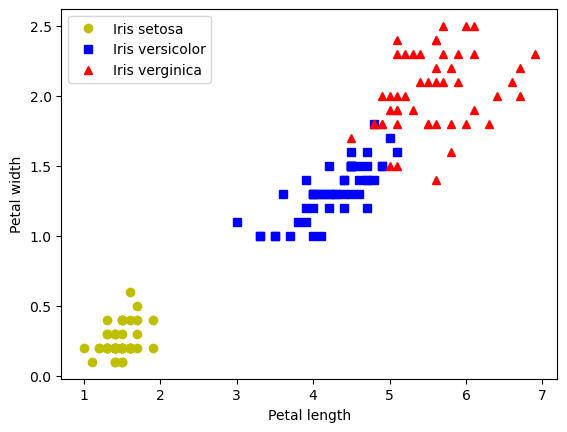

In [66]:
plt.plot(X_setosa[:, 0], X_setosa[:, 1], "yo", label="Iris setosa")             # 노랑 원
plt.plot(X_versicolor[:, 0], X_versicolor[:, 1], "bs", label="Iris versicolor") # 파랑 네모
plt.plot(X_verginica[:, 0], X_verginica[:, 1], "r^", label="Iris verginica")    # 빨강 세모

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")

plt.show()

범위를 x 축은 0에서 7.5 사이로, 
y 축은 0에서 3 사이로 지정한 다음에
축의 척도를 일치 시키면 그림이 사뭇 다르게 보인다.

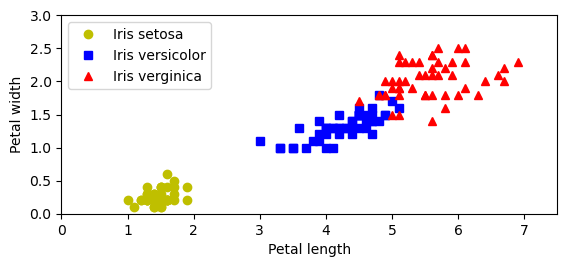

In [67]:
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo", label="Iris setosa")     # 노랑 원
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs", label="Iris versicolor") # 파랑 네모
plt.plot(X[:, 0][y == 2], X[:, 1][y == 2], "r^", label="Iris verginica")  # 빨강 세모

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")

plt.axis([0, 7.5, 0, 3])
plt.gca().set_aspect("equal")

plt.show()

격자 무늬 배경도 추가하자.

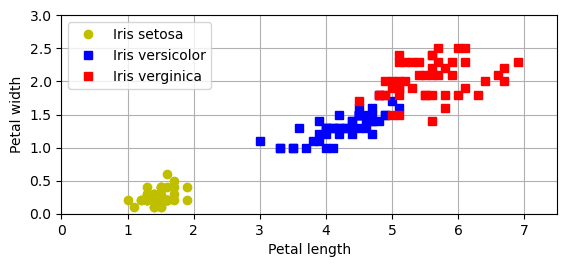

In [68]:
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo", label="Iris setosa")     # 노랑 원
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs", label="Iris versicolor") # 파랑 네모
plt.plot(X[:, 0][y == 2], X[:, 1][y == 2], "rs", label="Iris verginica")  # 빨강 세모

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")

plt.axis([0, 7.5, 0, 3])
plt.gca().set_aspect("equal")
plt.grid()

plt.show()

아래 코드는 두 개의 직선을 그린다.

In [102]:
a1, b1 = -2.37, 7.02
a2, b2 = -1.13, 7.17

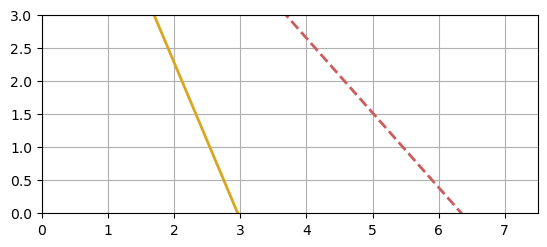

In [105]:
# 선 그래프
a1, b1 = -2.37, 7.02           # 첫째 직선의 기울기와 절편
a2, b2 = -1.13, 7.17           # 둘째 직선의 기울기와 절편

x0 = np.linspace(0, 7.5, 100)  # 0부터 7.5 사이의 100개의 x 좌표값
pred_setosa = a1 * x0 + b1     # 첫째 직선 y 좌표값
pred_virginica = a2 * x0 + b2  # 둘째 직선 y 좌표값

# 첫째 직선은 실선, 둘째 직선은 점선으로 그리기
plt.plot(x0, pred_setosa, color="goldenrod", linewidth=2)                
plt.plot(x0, pred_virginica, linestyle="--", color="indianred", linewidth=2)

# 축 범위 지정: x축은 0부터 7.5까지, y축은 0부터 3까지
plt.axis([0, 7.5, 0, 3])
# 종횡비 지정: x축과 y축의 단위 길이 통일
plt.gca().set_aspect("equal")
# 격자 추가
plt.grid()

plt.show()

위 두 직선과 붓꽃 데이터셋의 산포도를 합치면
품종을 구별하는 경계선을 얻는다.

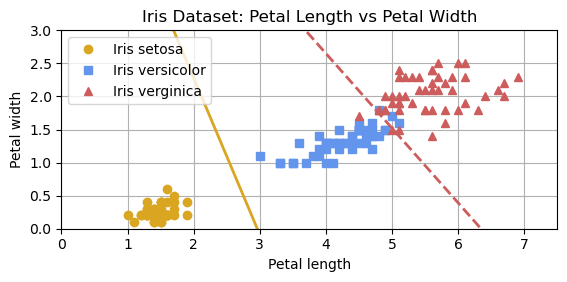

In [104]:
# 품종별 산점도
plt.plot(X[:, 0][y==0], X[:, 1][y==0], 
         marker="o", linestyle="", color="goldenrod", 
         label="Iris setosa")     # 노랑 원
plt.plot(X[:, 0][y==1], X[:, 1][y==1], 
         marker="s", linestyle="", color="cornflowerblue", 
         label="Iris versicolor") # 파랑 네모
plt.plot(X[:, 0][y==2], X[:, 1][y==2], 
         marker="^", linestyle="", color="indianred", 
         label="Iris verginica")  # 빨강 세모

# 구분선 그래프
a_setosa, b_setosa = -2.37, 7.02                # 세토사 구분선의 기울기와 절편
a_verginica, b_verginica = -1.13, 7.17          # 버지니카 구분선의 기울기와 절편

x0 = np.linspace(0, 7.5, 100)                    # 0부터 7.5 사이의 100개의 x 좌표값
pred_setosa = a_setosa * x0 + b_setosa           # 세토사 구분선에 대한 y 좌표값
pred_virginica = a_verginica * x0 + b_verginica  # 버지니카 구분선에 대한 y 좌표값

plt.plot(x0, pred_setosa, 
         color="goldenrod", linewidth=2)                 # 세토사 구분선
plt.plot(x0, pred_virginica, 
         linestyle="--", color="indianred", linewidth=2) # 버지니카 구분선

# 그래프 제목
plt.title("Iris Dataset: Petal Length vs Petal Width")
# 축 이름
plt.xlabel("Petal length")
plt.ylabel("Petal width")

# 범례: 마커의 색상과 모양에 따른 품종 확인
plt.legend(loc="upper left")
# 축 범위 지정: x축은 0부터 7.5까지, y축은 0부터 3까지
plt.axis([0, 7.5, 0, 3])
# 종횡비 지정: x축과 y축의 단위 길이 통일
plt.gca().set_aspect("equal")
# 격자 추가
plt.grid()

# 그래프 출력
plt.show()